In [1]:
import sys
import re
import os
import cv2
import pandas as pd
import seaborn as sns
import numpy as np
import ipywidgets as widgets
import matplotlib.pyplot as plt
import glob
import random
from pathlib import Path

In [2]:
import torch
from torch import nn

from torch.utils.data import DataLoader
from torch.utils.data import Dataset

from torchvision import datasets, transforms
from torchvision.utils import make_grid

# Note: this notebook requires torch >= 1.10.0
torch.__version__

'2.12.1+cu130'

In [3]:
# Setup device-agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

1. Configure Base Paths

In [4]:
ROOT_DIR = Path.cwd().parent.parent
sys.path.insert(0, str(ROOT_DIR / "src"))

print(ROOT_DIR)

/home/samuel-linux/master-degree-project


In [18]:
DATASET_DATA = ROOT_DIR / "data" / "UCF_Crime" / "processed" / "train_test_split"
DATASET_DATA

PosixPath('/home/samuel-linux/master-degree-project/data/UCF_Crime/processed/train_test_split')

In [19]:
from src.data.loaders import read_train_test_data_txt

train_files = read_train_test_data_txt(DATASET_DATA, "Anomaly_Train")
test_files = read_train_test_data_txt(DATASET_DATA, "Anomaly_Test")

In [20]:
print(f"Number of files: {len(train_files)}")
print(f"Type: {type(train_files)}")
print(f"Type of first element: {type(train_files[0])}")

print("\nFirst 5 entries:")
for item in train_files[:5]:
    print(item)

Number of files: 1610
Type: <class 'list'>
Type of first element: <class 'str'>

First 5 entries:
Abuse/Abuse001_x264.mp4
Abuse/Abuse002_x264.mp4
Abuse/Abuse003_x264.mp4
Abuse/Abuse004_x264.mp4
Abuse/Abuse005_x264.mp4


In [21]:
from collections import Counter

class_counts = Counter(item.split("/")[0] for item in train_files)

print("\nVideos per class:")
for cls, count in sorted(class_counts.items()):
    print(f"{cls:<15} {count}")


Videos per class:
Abuse           48
Arrest          45
Arson           41
Assault         47
Burglary        87
Explosion       29
Fighting        45
RoadAccidents   127
Robbery         145
Shooting        27
Shoplifting     29
Stealing        95
Training_Normal_Videos_Anomaly 800
Vandalism       45


In [12]:
def plot_class_distribution(data_files, title="training"):
  # Count videos per class
  class_counts = Counter(item.split("/")[0] for item in data_files)

  # Convert to DataFrame
  df = (
    pd.DataFrame(class_counts.items(), columns=["Class", "Count"])
    .sort_values("Count", ascending=False)
  )

  # Plot
  plt.figure(figsize=(12, 6))
  sns.barplot(data=df, x="Class", y="Count")

  plt.title(f"{title} Set Class Distribution")
  plt.xlabel("Class")
  plt.ylabel("Number of Videos")
  plt.xticks(rotation=45, ha="right")

  # Show count on top of each bar
  for i, count in enumerate(df["Count"]):
    plt.text(i, count + 0.5, str(count), ha="center", fontsize=9)

  plt.tight_layout()
  plt.show()

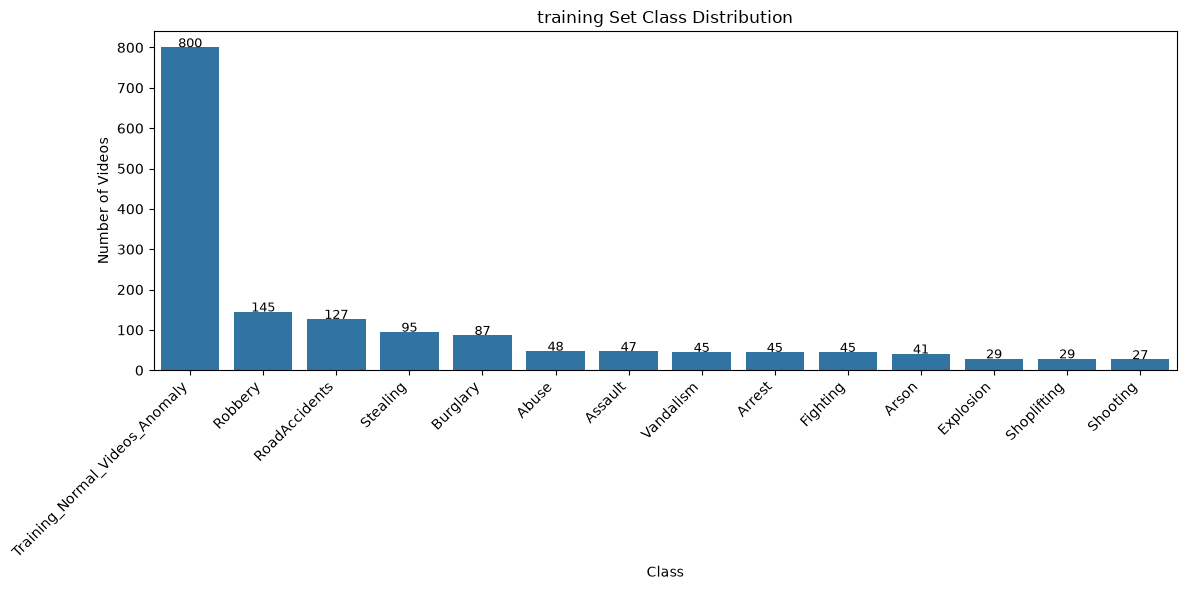

In [13]:
plot_class_distribution(train_files, "training")

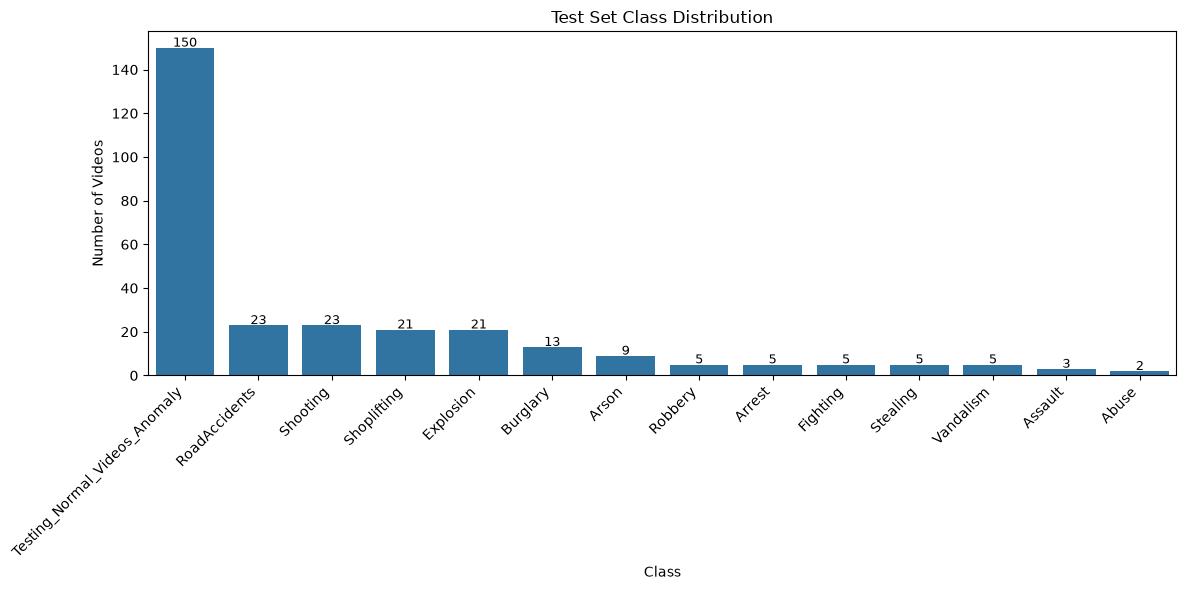

In [22]:
plot_class_distribution(test_files, "Test")

2. Explore Dataset

In [8]:
def dataset_frames_labels(dataset_path: Path, rand_num: int):
  frames = []
  labels = []
  
  classes_names = os.listdir(dataset_path)
  
  for class_name in classes_names:
    videos_path = dataset_path / class_name
    video_path = list(videos_path.glob("*.mp4"))[rand_num]
  
    cap = cv2.VideoCapture(video_path)
    
    if not cap.isOpened():
      print("Error: Could not open the video file.")
      return
      
    ret, frame = cap.read()
    
    if not ret:
      break
    
    frames.append(frame)
    labels.append(video_path.name)
    
  return frames, labels
        
        

In [12]:
# fig, axes = plt.subplots(3, 5, figsize=(10, 8))

# for ax, frame, label in zip(axes.flatten(), frames, labels):
#   ax.imshow(frame)
#   ax.set_title(label)
#   ax.axis("off")

# plt.tight_layout()
# plt.show()

3. Custom Dataset

In [10]:
class CustomVideoDataset(Dataset):
  def __init__(self, root_dir, num_frames=16, transform=None):
    """
    Args:
        root_dir (str): Path to the dataset directory (e.g., 'my_video_dataset/training')
        num_frames (int): Number of frames to sample from each video.
        transform (callable, optional): PyTorch transforms to apply to each frame.
    """
    self.root_dir = root_dir
    self.num_frames = num_frames
    self.transform = transform
      
    # Get class names and map them to integers
    self.classes = sorted(os.listdir(root_dir))
    # self.idx_to_class = {i: cls_name for cls_name, i in self.classes}
    self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.classes)}
      
    # Gather all video file paths and labels
    self.video_samples = []
    for cls_name in self.classes:
      cls_dir = os.path.join(root_dir, cls_name)
      if os.path.isdir(cls_dir):
        for file_name in os.listdir(cls_dir):
          if file_name.lower().endswith(('.mp4', '.avi', '.mov', '.mkv')):
            self.video_samples.append((os.path.join(cls_dir, file_name), self.class_to_idx[cls_name]))

  def __len__(self):
    return len(self.video_samples)

  def __getitem__(self, idx):
    video_path, label = self.video_samples[idx]
    
    # Capture frames from video
    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    
    if total_frames <= 0:
      raise ValueError(f"Error loading video or empty video file: {video_path}")
        
    # Calculate uniformly spaced frame indices
    seg_size = max(1, total_frames // self.num_frames)
    frame_indices = [min(total_frames - 1, i * seg_size) for i in range(self.num_frames)]
    
    frames = []
    for f_idx in frame_indices:
      cap.set(cv2.CAP_PROP_POS_FRAMES, f_idx)
      success, frame = cap.read()
      if not success:
        # Fallback to an empty/black frame if reading fails midway
        frame = torch.zeros((3, 224, 224)) if not self.transform else None
      else:
        # Convert BGR (OpenCV default) to RGB
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        if self.transform:
          frame = self.transform(frame)
              
      frames.append(frame)
        
    cap.release()
    
    # Stack frames into a single tensor
    # If your model expects shape (C, T, H, W) for 3D CNNs like ResNet3D:
    # permute channels after stacking.
    video_tensor = torch.stack(frames) # Shape: (T, C, H, W)
    video_tensor = video_tensor.permute(1, 0, 2, 3) # Shape: (C, T, H, W)
    
    return video_tensor, torch.tensor(label, dtype=torch.long)

In [11]:
# 1. Define Image/Frame transforms
# Video classification models typically require ImageNet or Kinetics normalization scales.
video_transforms = transforms.Compose([
  transforms.ToPILImage(),
  transforms.Resize((224, 224)),
  transforms.ToTensor(),
  transforms.Normalize(mean=[0.432, 0.394, 0.376], std=[0.228, 0.221, 0.216])
])

In [108]:
# 2. Instantiate Dataset
dataset = CustomVideoDataset(
  root_dir=DATA_PATH, 
  num_frames=32, 
  transform=video_transforms
)

In [82]:
dataset.class_to_idx

{'Abuse': 0,
 'Arrest': 1,
 'Arson': 2,
 'Assault': 3,
 'Burglary': 4,
 'Explosion': 5,
 'Fighting': 6,
 'RoadAccidents': 7,
 'Robbery': 8,
 'Shooting': 9,
 'Shoplifting': 10,
 'Stealing': 11,
 'Vandalism': 12}

In [114]:
dataset.classes[6]

'Fighting'

In [62]:
# 3. Create DataLoader
dataloader = DataLoader(dataset, batch_size=32, shuffle=True, num_workers=2)

In [63]:
# Get one video sample from dataloader
video, label = next(iter(dataloader))

In [96]:
label[15]

tensor(7)

In [66]:
# label_re = re.split(r"[0-9]+", label)[0]
# label_re

In [92]:
video.shape

torch.Size([32, 3, 32, 224, 224])

In [111]:
def video_dataloader_visualization(batch_of_videos, label, batch_num, normalized=False):
  # First video in the batch
  sample = batch_of_videos[batch_num]      # Shape: (3, 16, 224, 224)
  sample_label = label[batch_num]

  # Move frames to first dimension
  sample = sample.permute(1, 2, 3, 0)   # (16, 224, 224, 3)

  fig, axes = plt.subplots(6, 5, figsize=(10, 10))
  fig.suptitle(f"Batch {batch_num}/{batch_of_videos.shape[0]}")

  for i, ax in enumerate(axes.flat):
    frame = sample[i]

    if normalized:
      mean = torch.tensor([0.485, 0.456, 0.406])
      std = torch.tensor([0.229, 0.224, 0.225])
      frame = frame * std + mean

    frame = frame.clamp(0, 1)

    ax.imshow(frame)
    ax.set_title(f"{dataset.classes[sample_label]}: Frame {i+1}")
    ax.axis("off")

  plt.tight_layout()
  plt.show()

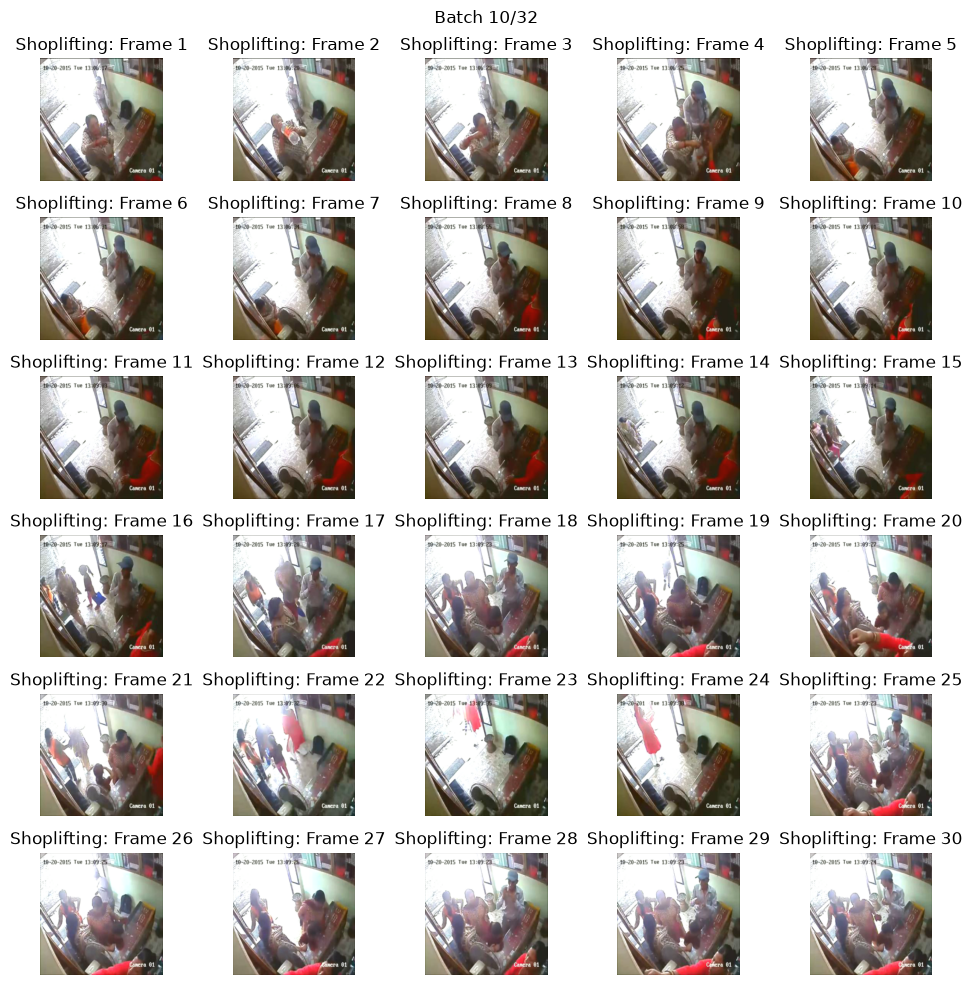

In [113]:
video_dataloader_visualization(video, label, 10, normalized=True)

In [20]:
for videos, labels in dataloader:
  print("Batch Video Shape:", videos.shape) # Expected: [Batch, Channels, Frames, Height, Width]
  print("Batch Labels Shape:", labels.shape)
  break

Batch Video Shape: torch.Size([32, 3, 16, 224, 224])
Batch Labels Shape: torch.Size([32])
